# **ANALYSIS WITH GAP_NOSOC FEATURE**

Reproducing results from ['Bandgap prediction of 2D materials using machine learning', https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0255637 ]

In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.3 MB/s eta 0:00:00


In [2]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot  as plt
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn import ensemble
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [22]:
df = pd.read_csv('/content/dosfinal.csv')

In [23]:
df.head()

,dosef,energy,natom,mass,fmax,smax,hform,volume,gap_nosoc,gap
0,0.0,-16.112529,4,247.734400,0.009337,0.000149,-0.046132,327.286639,0.159791,0.164045
1,0.0,-13.581981,4,279.856400,0.007039,0.000079,0.063505,380.909858,0.967953,0.961595
2,0.0,-12.556373,4,373.678400,0.009621,0.000034,0.022407,401.441237,0.869507,0.750715
3,0.0,-11.852202,4,470.936400,0.007429,0.000021,0.059449,459.020808,0.663121,0.478298
4,0.0,-16.546603,4,425.931138,0.005010,0.000360,-0.009651,322.649929,0.165582,0.175493


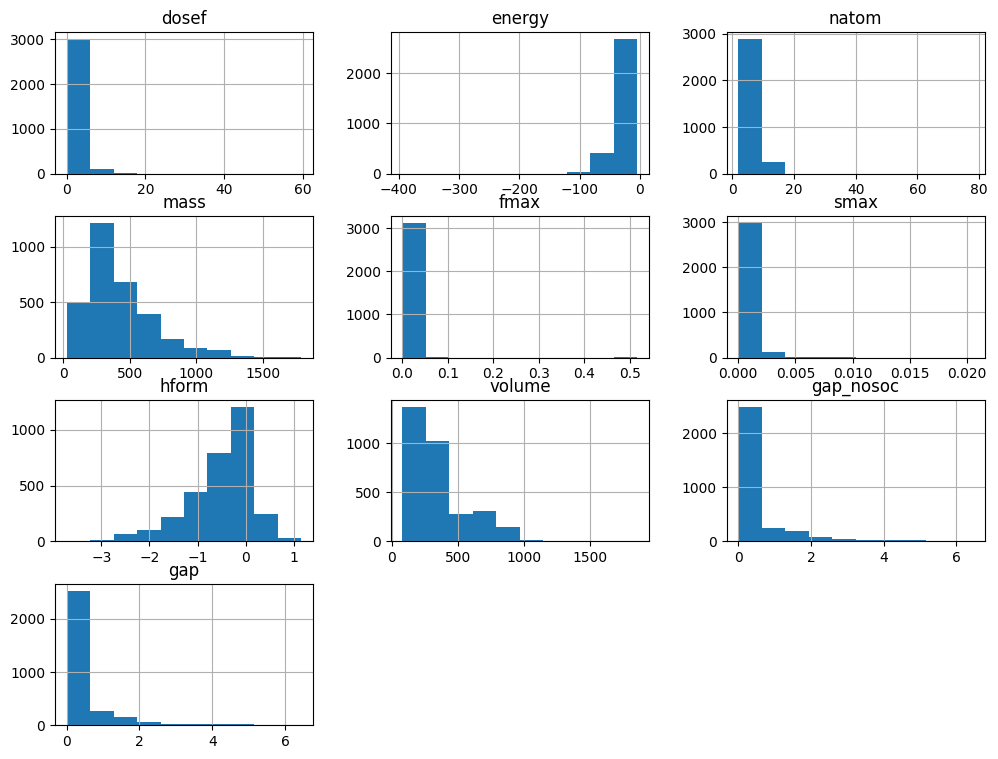

In [24]:
df.hist(figsize=(12, 9))
plt.show()


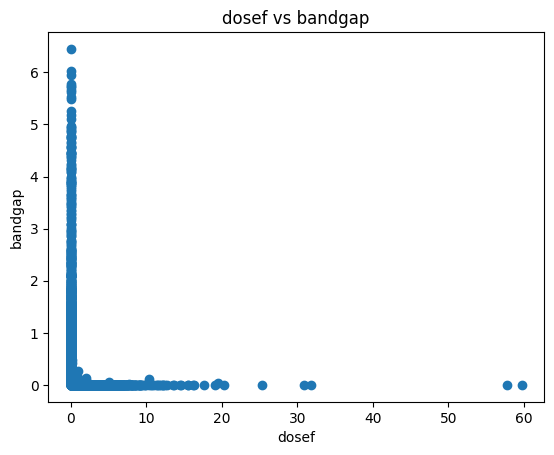

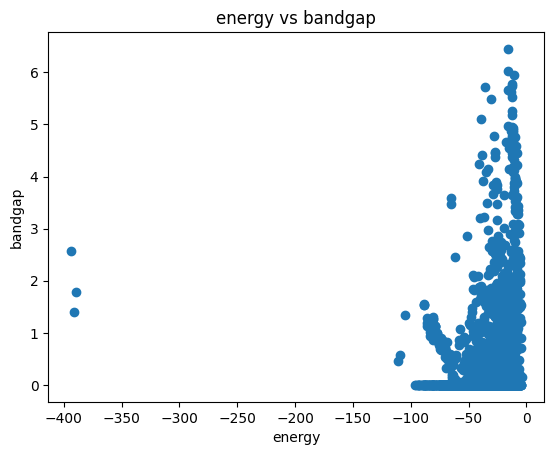

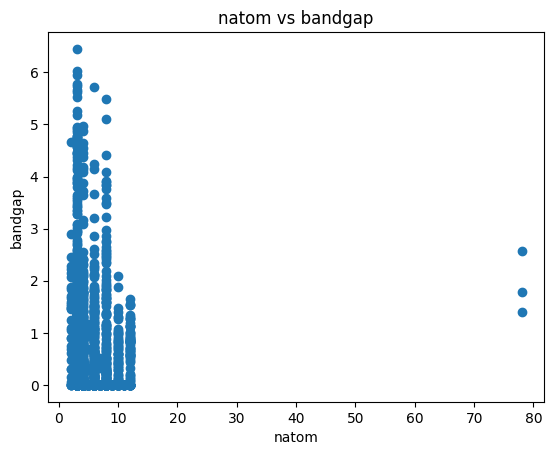

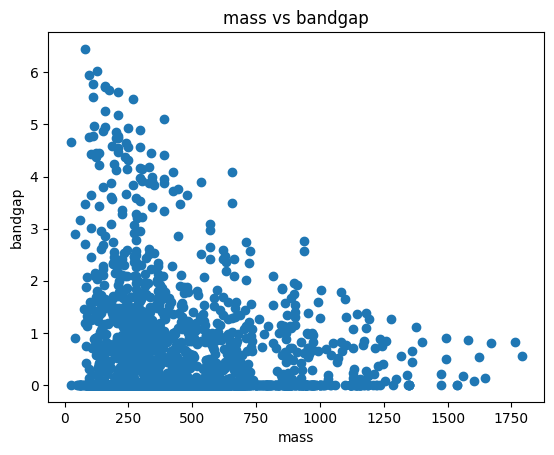

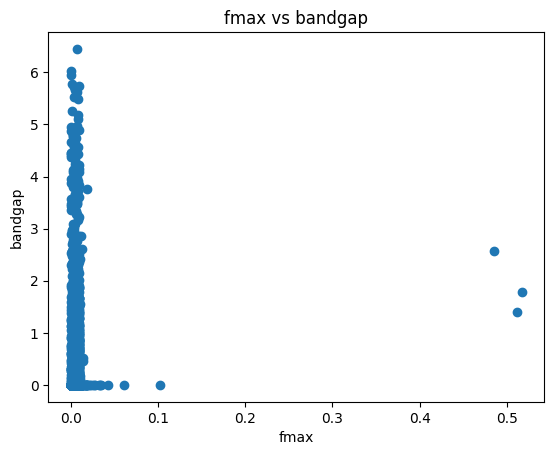

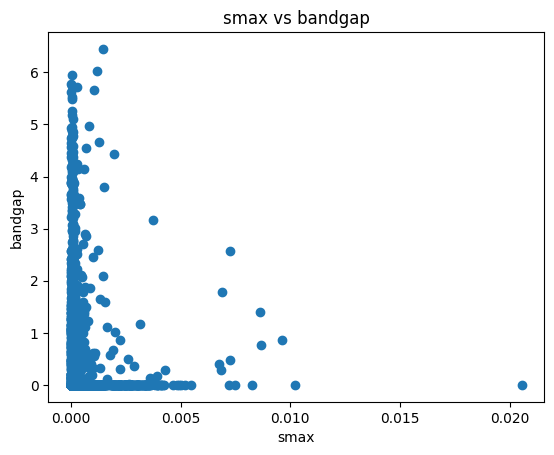

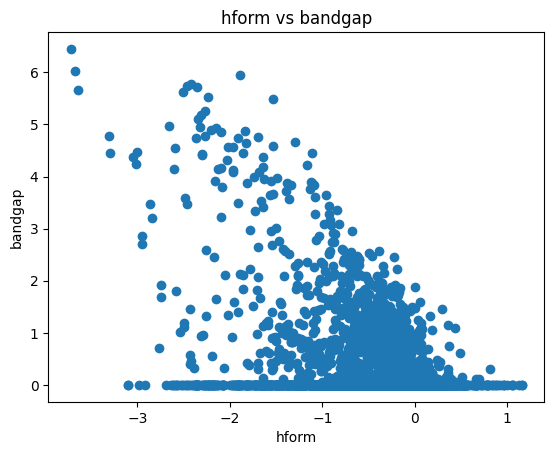

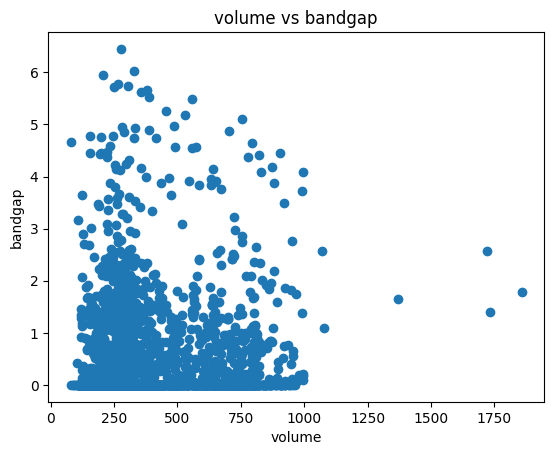

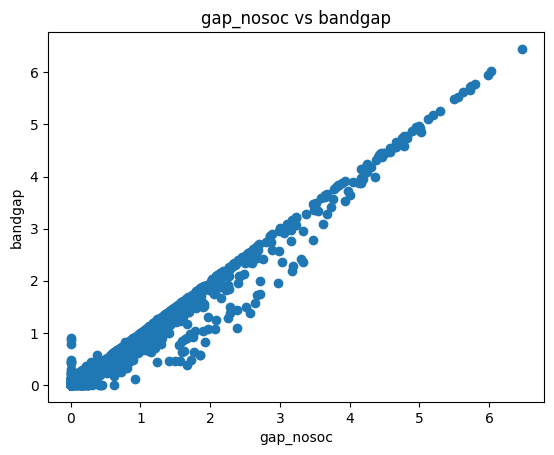

In [25]:
for i in range(9):
  plt.scatter(df.iloc[:,i], df.iloc[:,9])
  plt.xlabel(df.columns[i])
  plt.ylabel('bandgap')
  plt.title(f'{df.columns[i]} vs bandgap')
  plt.show()


In [38]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0:9], df.iloc[:, 9], test_size = 0.1, random_state = 0)

In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **SVR**

In [40]:
kernel = 'rbf'
C = [50]
gamma = [50]
epsilon = [0.2]

In [41]:
params_dict = {
	'C': C,
	'gamma': gamma,
	'epsilon': epsilon
}

In [42]:
svr = SVR()
gscv = GridSearchCV(
    estimator = svr,
    param_grid = params_dict,
    n_jobs = 2,
    scoring = 'r2',
    cv = 6
)
gscv.fit(X_train, y_train)

GridSearchCV(cv=6, estimator=SVR(), n_jobs=2,
             param_grid={'C': [50], 'epsilon': [0.2], 'gamma': [50]},
             scoring='r2')

In [43]:
svr = SVR(C=gscv.best_params_['C'], kernel=kernel, gamma=gscv.best_params_['gamma'],
      	epsilon=gscv.best_params_['epsilon'])
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)

In [44]:
print("Model evaluation - SVR:")
print('r^2:',r2_score(y_test, svr_pred))
print('RSE', mean_squared_error(y_test, svr_pred))
print('RAE', mean_absolute_error(y_test, svr_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,svr_pred)))

Model evaluation - SVR:
r^2: 0.9556084691862528
RSE 0.030171820367956192
RAE 0.11719010818401253
RMSE: 0.17370037526717147


# **RANDOM FOREST**

In [46]:
rf=RandomForestRegressor(criterion='absolute_error',bootstrap=False,max_features=0.8,
max_depth=20,min_samples_split=5, n_estimators=100,min_samples_leaf=3,random_state=0, n_jobs = -1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [47]:
print("Model evaluation - Random Forest:")
print('r^2:',r2_score(y_test, rf_pred))
print('RSE', mean_squared_error(y_test, rf_pred))
print('RAE', mean_absolute_error(y_test, rf_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,rf_pred)))

Model evaluation - Random Forest:
r^2: 0.9824285536445616
RSE 0.011942875438692518
RAE 0.03725174158611818
RMSE: 0.10928346370193671


# **GRADIENT BOOSTING**

In [48]:
params = {'n_estimators':200, 'max_depth': 21, 'min_samples_split': 5,
          'max_features':0.8,'learning_rate': 0.02, 'loss': 'squared_error',
          'random_state':0,'subsample': 0.85}
gbr = ensemble.GradientBoostingRegressor(**params)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

In [49]:
print("Model evaluation - Gradient Boosting:")
print('r^2:',r2_score(y_test, gbr_pred))
print('RSE', mean_squared_error(y_test, gbr_pred))
print('RAE', mean_absolute_error(y_test, gbr_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,gbr_pred)))

Model evaluation - Gradient Boosting:
r^2: 0.9871191821197179
RSE 0.008754771825887875
RAE 0.041025084665997406
RMSE: 0.09356693767505633


# **MULTILAYER PERCEPTRON**

In [50]:
from sklearn.neural_network import MLPRegressor

In [51]:
mlp_hw = MLPRegressor(solver='adam',hidden_layer_sizes=(262,140,139,180),activation='tanh',alpha=1e-8,
                 	tol=1e-6,max_iter=5000,learning_rate='constant',
                 	learning_rate_init=0.001,random_state=120)
mlp_hw.fit(X_train, y_train)

MLPRegressor(activation='tanh', alpha=1e-08,
             hidden_layer_sizes=(262, 140, 139, 180), max_iter=5000,
             random_state=120, tol=1e-06)

In [52]:
mlp_pred = mlp_hw.predict(X_test)

In [53]:
print("Model evaluation - Multi layer perceptron:")
print('r^2:',r2_score(y_test, mlp_pred))
print('RSE', mean_squared_error(y_test, mlp_pred))
print('RAE', mean_absolute_error(y_test, mlp_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,mlp_pred)))

Model evaluation - Multi layer perceptron:
r^2: 0.9600613328565015
RSE 0.027145319584609983
RAE 0.0835916311646519
RMSE: 0.16475836726737123


# **MODEL ANALYSIS**

In [54]:
analysis_result = {
    'Model' : ['SVR', 'RF', 'GBDT', 'MLP'],
    'R^2' : [r2_score(y_test, svr_pred), r2_score(y_test, rf_pred),
             r2_score(y_test, gbr_pred), r2_score(y_test, mlp_pred)],
    'RSE' : [mean_squared_error(y_test, svr_pred), mean_squared_error(y_test, rf_pred),
             mean_squared_error(y_test, gbr_pred), mean_squared_error(y_test, mlp_pred)],
    'RAE' : [mean_absolute_error(y_test, svr_pred), mean_absolute_error(y_test, rf_pred),
             mean_absolute_error(y_test, gbr_pred), mean_absolute_error(y_test, mlp_pred)],
    'RMSE' : [np.sqrt(mean_squared_error(y_test,svr_pred)),
              np.sqrt(mean_squared_error(y_test,rf_pred)),
              np.sqrt(mean_squared_error(y_test,gbr_pred)),
              np.sqrt(mean_squared_error(y_test,mlp_pred))]

}

results = pd.DataFrame(analysis_result)
results

,Model,R^2,RSE,RAE,RMSE
0,SVR,0.955608,0.030172,0.117190,0.173700
1,RF,0.982429,0.011943,0.037252,0.109283
2,GBDT,0.987119,0.008755,0.041025,0.093567
3,MLP,0.960061,0.027145,0.083592,0.164758


In [55]:
def error_percentages(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    abs_err = np.abs(y_true - y_pred)
    mask = y_true > 0.05
    abs_err = abs_err[mask]
    total = len(abs_err)
    lt10 = np.sum(abs_err < 0.1)  / total * 100
    lt20 = np.sum((abs_err >= 0.1) & (abs_err < 0.2)) / total * 100
    gt20 = np.sum(abs_err >= 0.2) / total * 100
    return [lt10, lt20, gt20]
models = {
    'GBDT': error_percentages(y_test, gbr_pred),
    'RF':   error_percentages(y_test, rf_pred),
    'SVR':  error_percentages(y_test, svr_pred),
    'MLP':  error_percentages(y_test, mlp_pred),
}

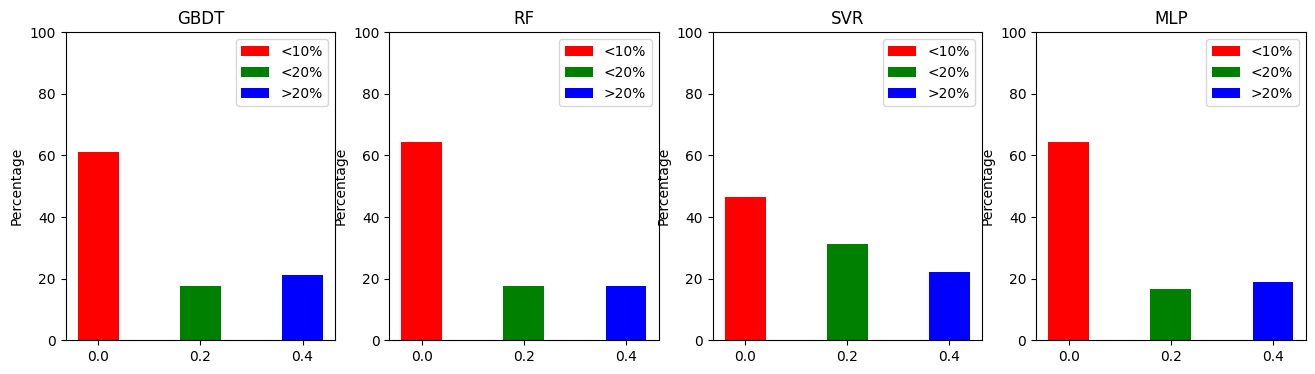

In [56]:
colors = ['red', 'green', 'blue']
labels = ['<10%', '<20%', '>20%']
x = [0.0, 0.2, 0.4]
bar_width = 0.08
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
model_names = list(models.keys())
model_values = list(models.values())
for i in range(4):
    ax = axes[i]
    model_name = model_names[i]
    percentages = model_values[i]
    ax.bar(x[0], percentages[0], width=bar_width, color=colors[0])
    ax.bar(x[1], percentages[1], width=bar_width, color=colors[1])
    ax.bar(x[2], percentages[2], width=bar_width, color=colors[2])
    ax.set_title(model_name)
    ax.set_ylabel('Percentage')
    ax.set_xticks(x)
    ax.set_xticklabels(['0.0', '0.2', '0.4'])
    ax.set_ylim(0, 100)
    ax.legend(labels)

plt.show()

In [57]:
svr_train_pred = svr.predict(X_train)
rf_train_pred = rf.predict(X_train)
gbr_train_pred = gbr.predict(X_train)
mlp_train_pred = mlp_hw.predict(X_train)

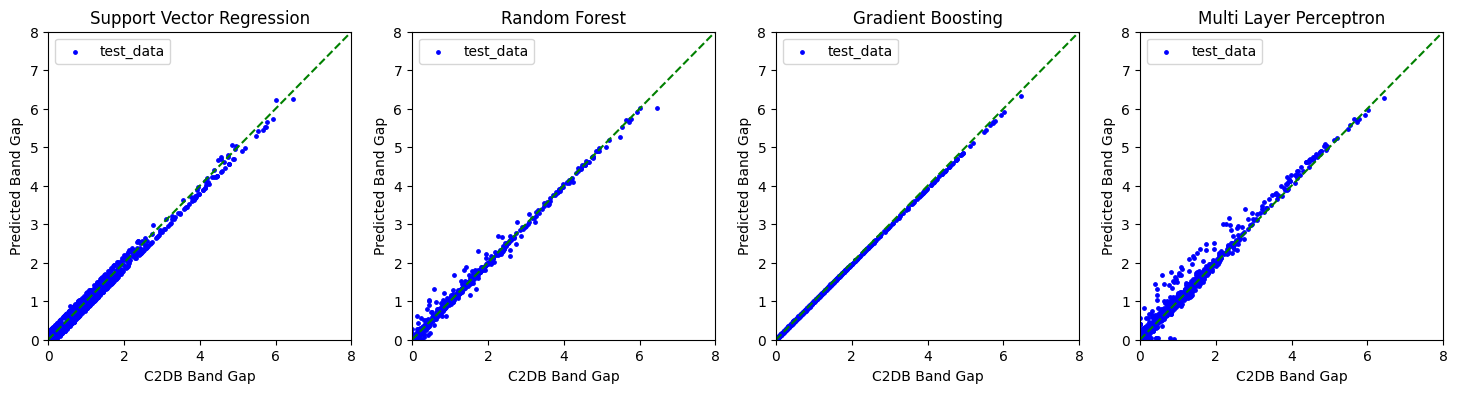

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names = ['Support Vector Regression', 'Random Forest', 'Gradient Boosting', 'Multi Layer Perceptron']
predictions = [svr_train_pred, rf_train_pred, gbr_train_pred, mlp_train_pred]
for i in range(4):
    ax = axes[i]
    name = model_names[i]
    prediction = predictions[i]
    ax.scatter(y_train, prediction,s = 6, color = 'blue')
    ax.plot([0, 8], [0, 8], linestyle='--',color = 'green')
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)

    ax.set_xlabel('C2DB Band Gap')
    ax.set_ylabel('Predicted Band Gap')
    ax.set_title(name)
    ax.legend(['test_data'])

plt.show()

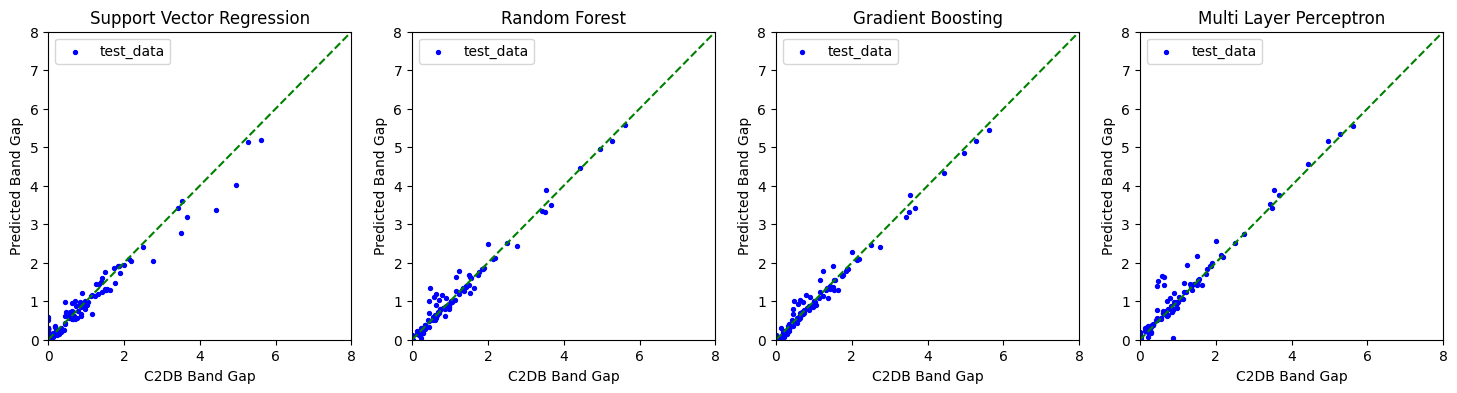

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names = ['Support Vector Regression', 'Random Forest', 'Gradient Boosting', 'Multi Layer Perceptron']
predictions = [svr_pred, rf_pred, gbr_pred, mlp_pred]
for i in range(4):
    ax = axes[i]
    name = model_names[i]
    prediction = predictions[i]
    ax.scatter(y_test, prediction,s = 8, color = 'blue')
    ax.plot([0, 8], [0, 8], linestyle='--',color = 'green')
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)

    ax.set_xlabel('C2DB Band Gap')
    ax.set_ylabel('Predicted Band Gap')
    ax.set_title(name)
    ax.legend(['test_data'])

plt.show()

PREVIOUS NOTEBOOL LINK - https://colab.research.google.com/drive/1E1bC04sSFteQXUk0GWHMEGcJAKrqPwZS?usp=sharing